# **Importing libraries**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/content/Superstore.csv', encoding='latin1')

# Quick look
print(df.head())
print(df.info())
print(df.describe())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

# **Data preprocessing**

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Year, Month, Quarter
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

# **Exploratory Data Analysis**

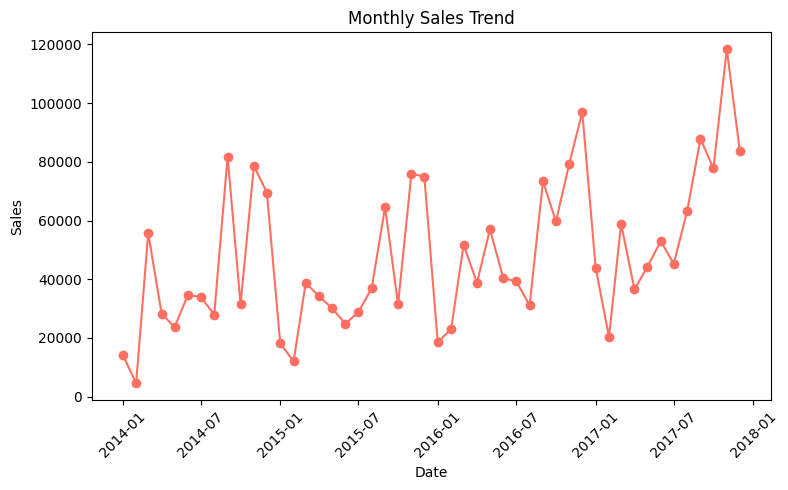

<Figure size 640x480 with 0 Axes>

In [26]:
# Monthly Sales Trend
monthly_sales = df.groupby(['Year','Month'])['Sales'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales.assign(DAY=1)[['Year','Month','DAY']])

plt.figure(figsize=(8,5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], color='#FF6F61', marker='o')
plt.title('Monthly Sales Trend', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('monthly_sales_trend.png')

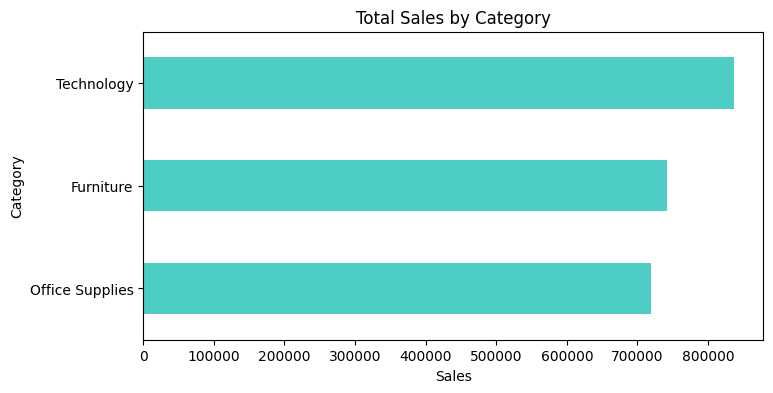

In [27]:
# Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
category_sales.plot(kind='barh', figsize=(8,4), color='#4ECDC4')
plt.title('Total Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')
plt.savefig('category_sales.png')
plt.show()


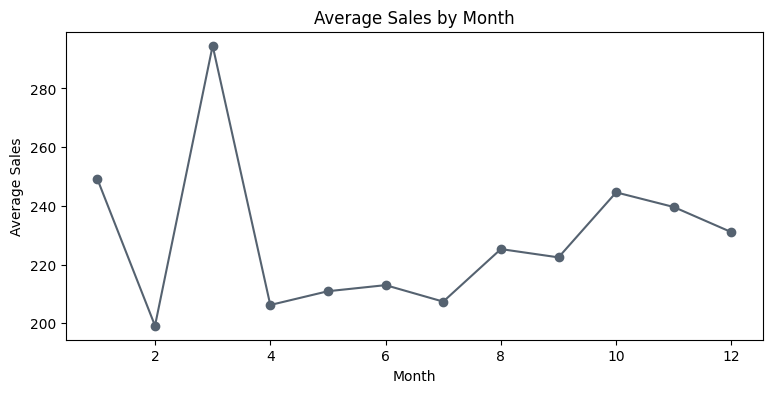

In [28]:
# Average Sales by Month
avg_month = df.groupby('Month')['Sales'].mean()
avg_month.plot(kind='line', figsize=(9,4), marker='o', color='#556270')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.savefig('avg_sales_month.png')
plt.show()

/tmp/ipykernel_18923/1399400360.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='Sales', data=df, palette='Set2')


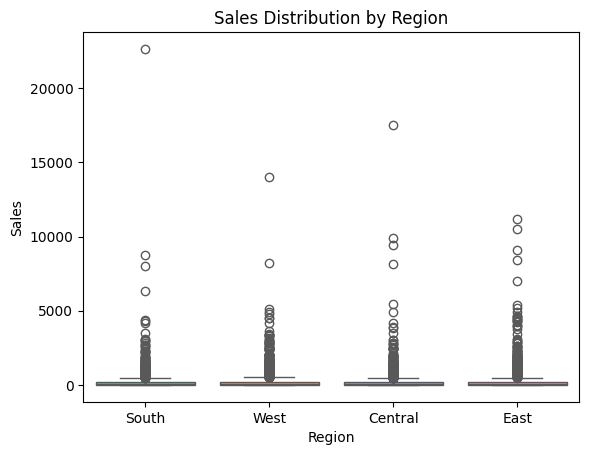

In [14]:
# Sales distribution by Region
sns.boxplot(x='Region', y='Sales', data=df, palette='Set2')
plt.title('Sales Distribution by Region')
plt.show()

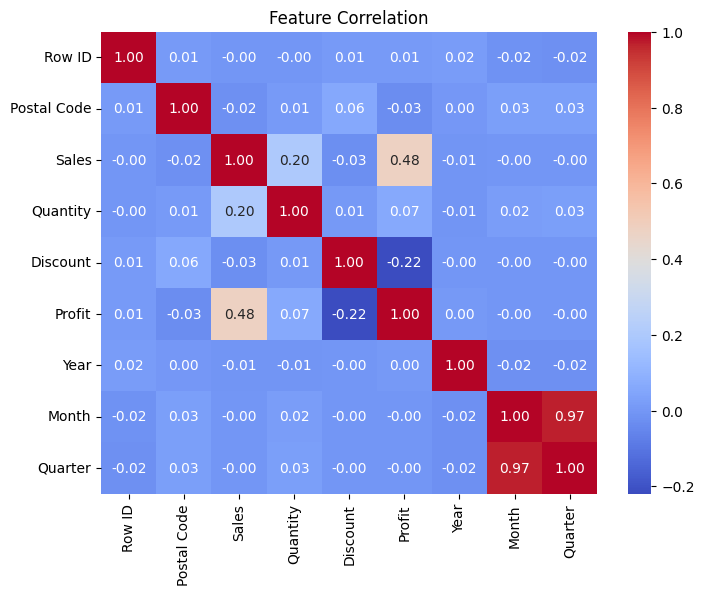

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation')
plt.savefig('feature_correlation.png')
plt.show()

# **Feature Engineering**

In [16]:
monthly_sales = monthly_sales.sort_values('Date')
monthly_sales['Sales_Lag1'] = monthly_sales['Sales'].shift(1)
monthly_sales['Sales_Lag3'] = monthly_sales['Sales'].shift(3)
monthly_sales['Sales_Lag12'] = monthly_sales['Sales'].shift(12)
monthly_sales['Rolling_Mean_3'] = monthly_sales['Sales'].rolling(3).mean()
monthly_sales['Rolling_Mean_6'] = monthly_sales['Sales'].rolling(6).mean()
monthly_sales['Rolling_Std_3'] = monthly_sales['Sales'].rolling(3).std()
monthly_sales.dropna(inplace=True)

# Extra features
monthly_sales['Month_Num'] = monthly_sales['Month']
monthly_sales['Quarter'] = monthly_sales['Date'].dt.quarter  # Added Quarter column
monthly_sales['IsQ4'] = (monthly_sales['Month'].isin([10,11,12])).astype(int)

# **Train-Test Split**

In [17]:
X_cols = ['Month_Num','Quarter','IsQ4','Year',
          'Sales_Lag1','Sales_Lag3','Sales_Lag12',
          'Rolling_Mean_3','Rolling_Mean_6','Rolling_Std_3']

X = monthly_sales[X_cols]
y = monthly_sales['Sales']

split_idx = len(X) - 6
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# **Modeling**

In [37]:
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

model_results = {}
y_pred_all = {}

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred = mdl.predict(X_test)
    y_pred_all[name] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    model_results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

results_df = pd.DataFrame(model_results).T.round(2).sort_values('R²', ascending=False)
best_model_name = results_df.index[0]
best_model = models[best_model_name]

#print("Model Performance:\n", results_df)
results_df.style.background_gradient(cmap='Blues')






,MAE,RMSE,R²
GradientBoosting,12438.560000,14690.940000,0.580000
LinearRegression,11228.240000,15272.120000,0.540000
RandomForest,13604.850000,17316.300000,0.410000


# **Feature Importance**

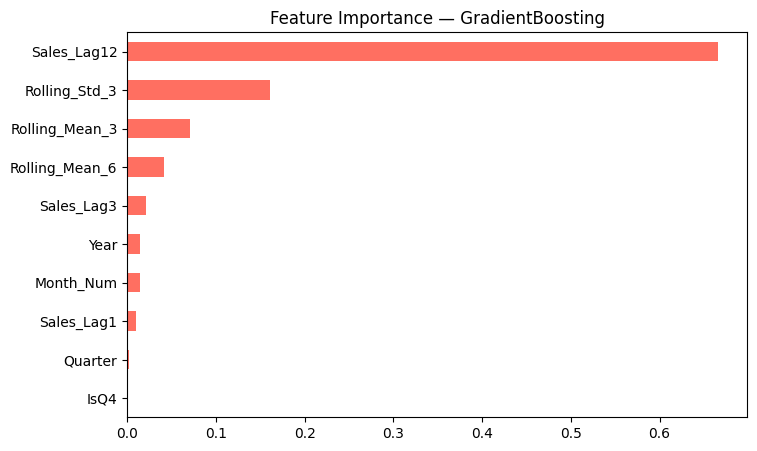

In [19]:
if hasattr(best_model,'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_, index=X_cols).sort_values()
    plt.figure(figsize=(8,5))
    feat_imp.plot(kind='barh', color='#FF6F61')
    plt.title(f'Feature Importance — {best_model_name}')
    plt.show()

# **Forecast Visualization**

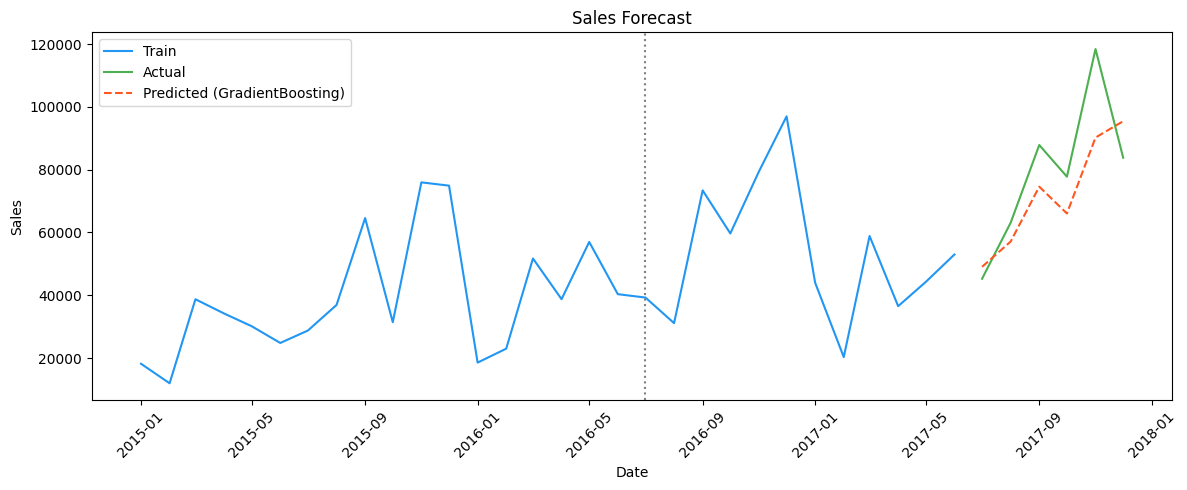

In [20]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'][:split_idx], y_train, label='Train', color='#2196F3')
plt.plot(monthly_sales['Date'][split_idx:], y_test, label='Actual', color='#4CAF50')
plt.plot(monthly_sales['Date'][split_idx:], y_pred_all[best_model_name],
         label=f'Predicted ({best_model_name})', color='#FF5722', linestyle='--')
plt.axvline(x=monthly_sales['Date'][split_idx], color='gray', linestyle=':')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Business Insights**

In [21]:
total_revenue = df['Sales'].sum()
total_profit = df['Profit'].sum()
avg_sales = monthly_sales['Sales'].mean()
profit_margin = total_profit / total_revenue * 100
best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax(),'Date'].strftime('%B %Y')
top_category = df.groupby('Category')['Sales'].sum().idxmax()
top_region = df.groupby('Region')['Sales'].sum().idxmax()

print(f"Total Revenue   : ${total_revenue:,.2f}")
print(f"Total Profit    : ${total_profit:,.2f}")
print(f"Average Monthly : ${avg_sales:,.2f}")
print(f"Profit Margin   : {profit_margin:.1f}%")
print(f"Best Month      : {best_month}")
print(f"Top Category    : {top_category}")
print(f"Top Region      : {top_region}")
print(f"Best Model      : {best_model_name} (R2={results_df.loc[best_model_name,'R2']})")

Total Revenue   : $2,297,200.86
Total Profit    : $286,397.02
Average Monthly : $50,359.82
Profit Margin   : 12.5%
Best Month      : November 2017
Top Category    : Technology
Top Region      : West
Best Model      : GradientBoosting (R2=0.58)


In [22]:
forecast_df = monthly_sales.copy()
future_predictions_list = []

for i in range(6):
    # a. Determine the next_date
    last_date = forecast_df['Date'].iloc[-1]
    next_date = last_date + pd.DateOffset(months=1)

    # b. Extract Year, Month_Num, Quarter, IsQ4
    future_year = next_date.year
    future_month_num = next_date.month
    future_quarter = next_date.quarter
    future_is_q4 = int(future_month_num in [10, 11, 12])

    # c. Calculate lagged sales features
    sales_lag1 = forecast_df['Sales'].iloc[-1]
    sales_lag3 = forecast_df['Sales'].iloc[-3]
    sales_lag12 = forecast_df['Sales'].iloc[-12]

    # d. Calculate rolling window features
    rolling_mean_3 = forecast_df['Sales'].iloc[-3:].mean()
    rolling_mean_6 = forecast_df['Sales'].iloc[-6:].mean()
    rolling_std_3 = forecast_df['Sales'].iloc[-3:].std()

    # e. Create a new pandas DataFrame for features for the next_date
    X_future = pd.DataFrame({
        'Month_Num': [future_month_num],
        'Quarter': [future_quarter],
        'IsQ4': [future_is_q4],
        'Year': [future_year],
        'Sales_Lag1': [sales_lag1],
        'Sales_Lag3': [sales_lag3],
        'Sales_Lag12': [sales_lag12],
        'Rolling_Mean_3': [rolling_mean_3],
        'Rolling_Mean_6': [rolling_mean_6],
        'Rolling_Std_3': [rolling_std_3]
    }, columns=X_cols) # Ensure column order matches X_cols

    # f. Predict the sales for this next_date
    predicted_sales = best_model.predict(X_future)[0]

    # g. Append this predicted sales value to the future_predictions_list
    future_predictions_list.append(predicted_sales)

    # h. Construct a new DataFrame row and append to forecast_df
    new_row = pd.DataFrame({
        'Year': [future_year],
        'Month': [future_month_num],
        'Sales': [predicted_sales],
        'Date': [next_date],
        'Sales_Lag1': [sales_lag1],
        'Sales_Lag3': [sales_lag3],
        'Sales_Lag12': [sales_lag12],
        'Rolling_Mean_3': [rolling_mean_3],
        'Rolling_Mean_6': [rolling_mean_6],
        'Rolling_Std_3': [rolling_std_3],
        'Month_Num': [future_month_num],
        'Quarter': [future_quarter],
        'IsQ4': [future_is_q4]
    })
    forecast_df = pd.concat([forecast_df, new_row], ignore_index=True)

print(f"Generated future predictions for {len(future_predictions_list)} months.")
print(forecast_df.tail(7))


Generated future predictions for 6 months.
    Year  Month         Sales       Date     Sales_Lag1     Sales_Lag3  \
35  2017     12  83829.318800 2017-12-01  118447.825000   87866.652000   
36  2018      1  65153.616221 2018-01-01   83829.318800   77776.923200   
37  2018      2  44210.744564 2018-02-01   65153.616221  118447.825000   
38  2018      3  66260.544098 2018-03-01   44210.744564   83829.318800   
39  2018      4  50428.819955 2018-04-01   66260.544098   65153.616221   
40  2018      5  56465.739952 2018-05-01   50428.819955   44210.744564   
41  2018      6  62826.956282 2018-06-01   56465.739952   66260.544098   

    Sales_Lag12  Rolling_Mean_3  Rolling_Mean_6  Rolling_Std_3  Month_Num  \
35   96999.0430    93351.355667    79384.337167   21943.847723         12   
36   43971.3740    93351.355667    79384.337167   21943.847723          1   
37   20301.1334    89143.586674    82699.203870   27041.620784          2   
38   58872.3528    64397.893195    79547.513297   19820.

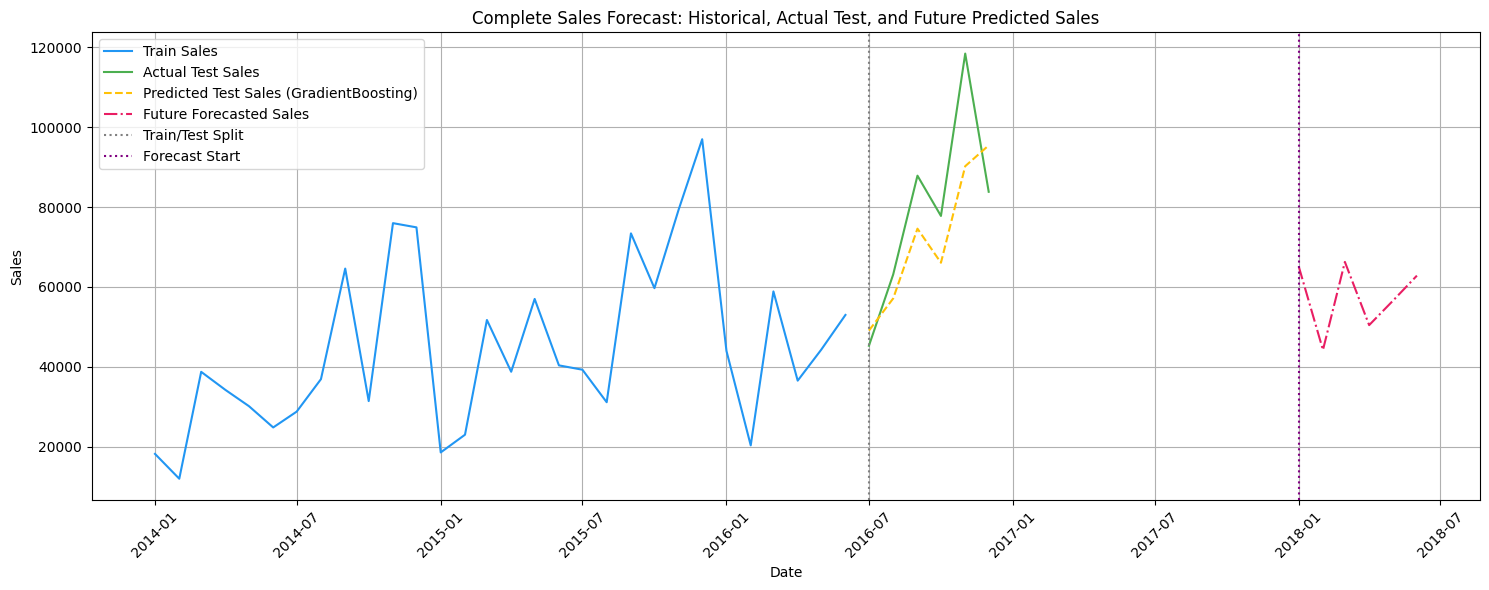

In [30]:
plt.figure(figsize=(15, 6))
plt.plot(monthly_sales['Date'][:split_idx], y_train, label='Train Sales', color='#2196F3')
plt.plot(monthly_sales['Date'][split_idx:split_idx + len(y_test)], y_test, label='Actual Test Sales', color='#4CAF50')

# Plot the predicted test sales
plt.plot(monthly_sales['Date'][split_idx:split_idx + len(y_test)], y_pred_all[best_model_name], label=f'Predicted Test Sales ({best_model_name})', color='#FFC107', linestyle='--')

# Plot the future forecasted sales
# The forecasted values are from index split_idx + len(y_test) up to the end of forecast_df
# Note: forecast_df includes monthly_sales data up to the last actual month (split_idx + len(y_test) - 1)
# and then 6 more months of forecasted data.
# We need to start plotting from the first forecasted month. The `future_predictions_list` contains only the 6 forecasted values.
# We can get the dates for the future forecast directly from the `forecast_df` that was built in the previous step.

future_forecast_dates = forecast_df['Date'].iloc[-len(future_predictions_list):]
future_forecast_sales = future_predictions_list

plt.plot(future_forecast_dates, future_forecast_sales, label='Future Forecasted Sales', color='#E91E63', linestyle='-.')

plt.axvline(x=monthly_sales['Date'][split_idx], color='gray', linestyle=':', label='Train/Test Split')
plt.axvline(x=future_forecast_dates.iloc[0], color='purple', linestyle=':', label='Forecast Start')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Complete Sales Forecast: Historical, Actual Test, and Future Predicted Sales')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('complete_sales_forecast.png')
plt.show()